In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from base_data_handler import BaseDataHandler

In [7]:
file_path = "california_housing_data.csv"
handler = BaseDataHandler(file_path)
cols = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude','MedHouseVal']

<Axes: xlabel='Longitude', ylabel='Latitude'>

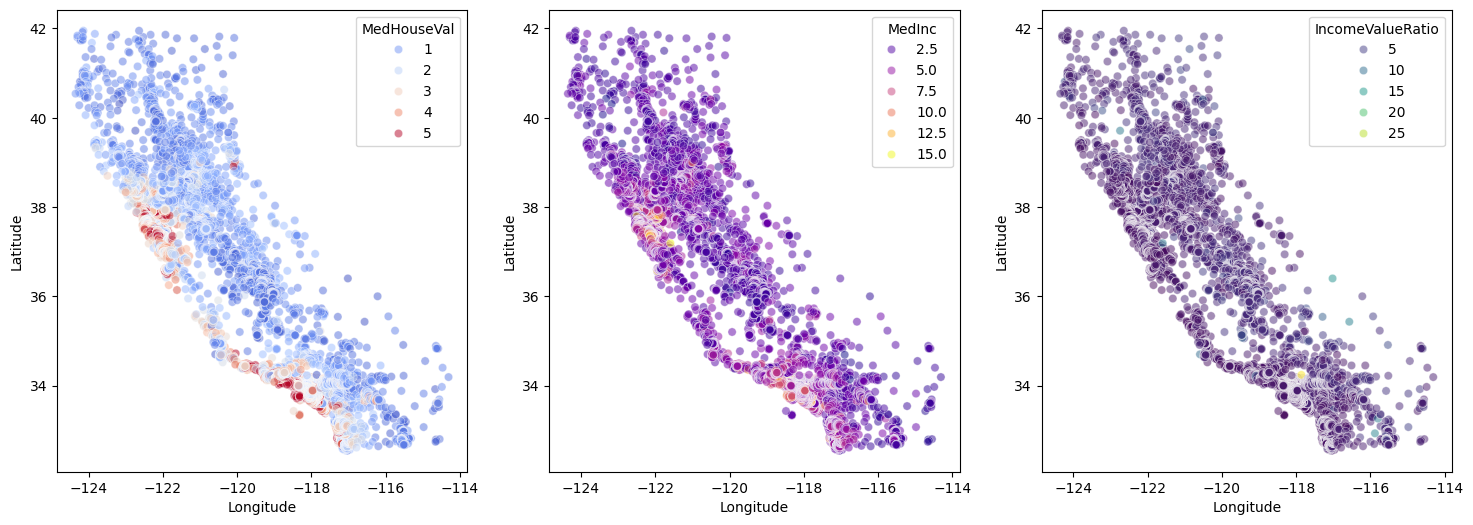

In [8]:
handler.try_fill_nan()
handler.try_remove_duplicates()
handler.try_add_col("IncomeValueRatio", lambda row: row['MedInc'] / row['MedHouseVal'])
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(x="Longitude", y="Latitude", hue="MedHouseVal", data=handler.df, ax=axs[0], palette="coolwarm", alpha=0.5)
sns.scatterplot(x="Longitude", y="Latitude", hue="MedInc", data=handler.df, ax=axs[1], palette="plasma", alpha=0.5)
sns.scatterplot(x="Longitude", y="Latitude", hue="IncomeValueRatio", data=handler.df, ax=axs[2], palette="viridis", alpha=0.5)

<Axes: xlabel='HouseAge', ylabel='MedHouseVal'>

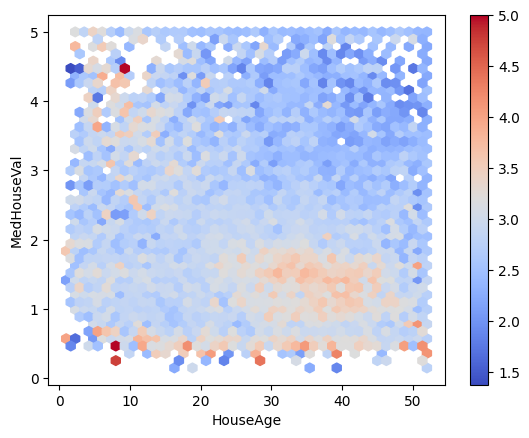

In [9]:
handler.try_clamp_cols(['AveOccup'], lower_bounds=[0], upper_bounds=[5])
handler.df.plot.hexbin(x="HouseAge", y="MedHouseVal",C="AveOccup", reduce_C_function=np.mean,gridsize=40, cmap="coolwarm")